In [1]:

import wandb
import pandas as pd

# Initialize the API
api = wandb.Api()

# Specify your entity (username or team name) and project name
entity = "vlm_rl" 
project = "rpp_ke_ablation"

# Get all runs in the project
runs = api.runs(f"{entity}/{project}")

import json
bad_episodes = json.loads(open('/Projects/spatial_training/conf/episode_jsons/sample400_a_blacklist.json').read())
rl_sr = []
rl_spl = []
for run in runs:
    # 'blacklist' should be a list, set, or array
    df = run.history()
    clean_df = df[~df['episode_label'].isin(bad_episodes)]
    true_success=clean_df["success"]*(clean_df['fpg_trigger_count']<1)*(clean_df['sup/sum_spguard_trigger_count']<1)
    true_spl=clean_df["spl"]*(clean_df['fpg_trigger_count']<1)*(clean_df['sup/sum_spguard_trigger_count']<1)
    rl_sr.append(true_success.mean())
    rl_spl.append(true_spl.mean())
print(rl_sr)
rl_ckpt = [int(run.name.split("_")[-1]) for run in runs]
print(rl_ckpt)

wandb: Currently logged in as: axi42 (vlm_rl) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[0.75, 0.6420454545454546, 0.64, 0.7247191011235955, 0.735632183908046, 0.5909090909090909, 0.7167630057803468, 0.7267080745341615, 0.4540229885057471]
[263, 151, 55, 215, 231, 23, 71, 271, 0]


In [2]:
entity = "vlm_rl" 
project = "sft_ablation"

# Get all runs in the project
runs = api.runs(f"{entity}/{project}")
sft_sr = []
sft_spl = []
for run in runs:
    # 'blacklist' should be a list, set, or array
    df = run.history()
    clean_df = df[~df['episode_label'].isin(bad_episodes)]
    true_success = clean_df["success"]*(clean_df["fpg_trigger_count"] < 1)
    true_spl = clean_df["spl"]*(clean_df["fpg_trigger_count"] < 1)
    sft_sr.append(true_success.mean())
    sft_spl.append(true_spl.mean())
print(sft_sr)
sft_ckpt = [int(run.name.split("_")[-1]) for run in runs]
print(sft_ckpt)


[0.6022727272727273, 0.6457142857142857, 0.48295454545454547, 0.5470588235294118, 0.4567901234567901]
[7700, 3500, 1500, 5000, 500]


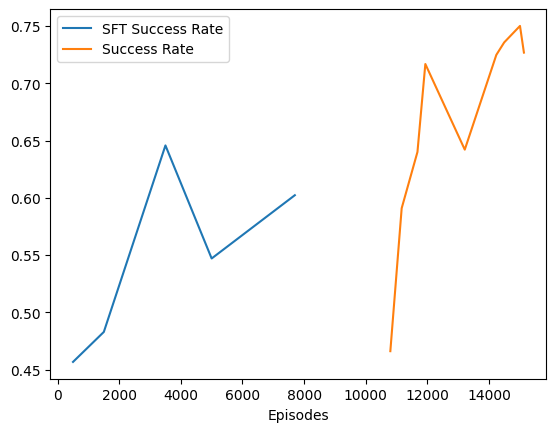

In [33]:
import matplotlib.pyplot as plt

import numpy as np

rl_ckpt = np.array(rl_ckpt)
rl_sr = np.array(rl_sr)
sort_indices = rl_ckpt.argsort()
rl_ckpt = rl_ckpt[sort_indices]
rl_step = rl_ckpt*16+10800
rl_sr = rl_sr[sort_indices]
rl_spl = np.array(rl_spl)[sort_indices]

sft_ckpt = np.array(sft_ckpt)
sft_sr = np.array(sft_sr)
sort_indices = sft_ckpt.argsort()
sft_ckpt = sft_ckpt[sort_indices]
sft_step = sft_ckpt
sft_sr = sft_sr[sort_indices]
sft_spl = np.array(sft_spl)[sort_indices]
plt.plot(sft_step,sft_sr,label="SFT Success Rate")
plt.plot(rl_step,rl_sr,label="Success Rate")

# plt.plot(rl_step,rl_spl,label="SPL")
plt.xlabel("Episodes")
plt.legend()

In [17]:
plt.plot(sft_step,sft_spl,label="SFT SPL")
plt.plot(rl_step,rl_spl,label="RL SPL")

# plt.plot(rl_step,rl_spl,label="SPL")
plt.xlabel("Episodes")
plt.legend()

NameError: name 'plt' is not defined

In [ ]:

run = api.run("/vlm_rl/new_rl_hm3d_v1_full/runs/y71bb2l0") #231
history = run.history()
true_success = (history['fpg_trigger_count'] < 1) * history['success']#*(history['sup/sum_spguard_trigger_count']<1)
true_spl = (history['fpg_trigger_count'] < 1) * history['spl']#*(history['sup/sum_spguard_trigger_count']<1)
history['true_success'] = true_success
history['true_spl'] = true_spl

KeyError: 'sup/sum_spguard_trigger_count'

In [16]:
run = api.run("/vlm_rl/rl_eval/runs/ekzl8k6p")
history_2 = run.history()
true_success = (history_2['fpg_trigger_count'] < 1) * history_2['success']#*(history['sup/sum_spguard_trigger_count']<1)
true_spl = (history_2['fpg_trigger_count'] < 1) * history_2['spl']#*(history['sup/sum_spguard_trigger_count']<1)
history_2['true_success'] = true_success
history_2['true_spl'] = true_spl

In [14]:
common_eps = set(history_2['episode_label']).intersection(set(history['episode_label']))
hist1_filtered = history[history['episode_label'].isin(common_eps)]
hist2_filtered = history_2[history_2['episode_label'].isin(common_eps)]
print(hist1_filtered['true_success'].mean(),hist2_filtered['true_success'].mean())
print(hist1_filtered['true_spl'].mean(),hist2_filtered['true_spl'].mean())

0.7786885245901639 0.7950819672131147
0.46788986941242583 0.49048957852057573
